In [4]:
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
import torch
import os

import_path = Path.cwd().parent
print(import_path)
os.sys.path.insert(0, str(import_path))
import utilities.feature_utils as futils
import utilities.utils as utils

/Users/johan/uni/bachelor/project


In [8]:
# feat_path = Path(r"D:\second_extraction")
# uw_log_mel_path = r"D:\logmel_outputs_9979"

feat_path = Path.cwd().parent / "testDirDeleteMe" / "files" / "Aug_6229"
uw_log_mel_path = Path.cwd().parent / "testDirDeleteMe" / "files" / "Aug_6229"

key = "feature"

val1_path = feat_path / "6229.220808232000.npz"
val2_path = feat_path / "6229.220809054000.npz"
val3_path = feat_path / "6229.220809154000.npz"

# val1_path = r"D:\second_extraction\Tracy_6230\6230.220917120000.npz"
# val2_path = r"D:\second_extraction\Tracy_6230\6230.221003000000.npz"
# val3_path = r"D:\second_extraction\Tracy_6230\6230.220915010000.npz"

mels_start, mels_end, n_mels = 9, 61, 128
mels_used = mels_end - mels_start
sr = 64000
hop_length = 512
fps = sr / hop_length 
t_start, t_end = 25.0, 30.0
i_start = int(t_start * fps)
i_end = int(t_end * fps)

s1 = np.load(val1_path)[key]
spec1 = s1[0]
seg1 = spec1[mels_start:mels_end, i_start:i_end]

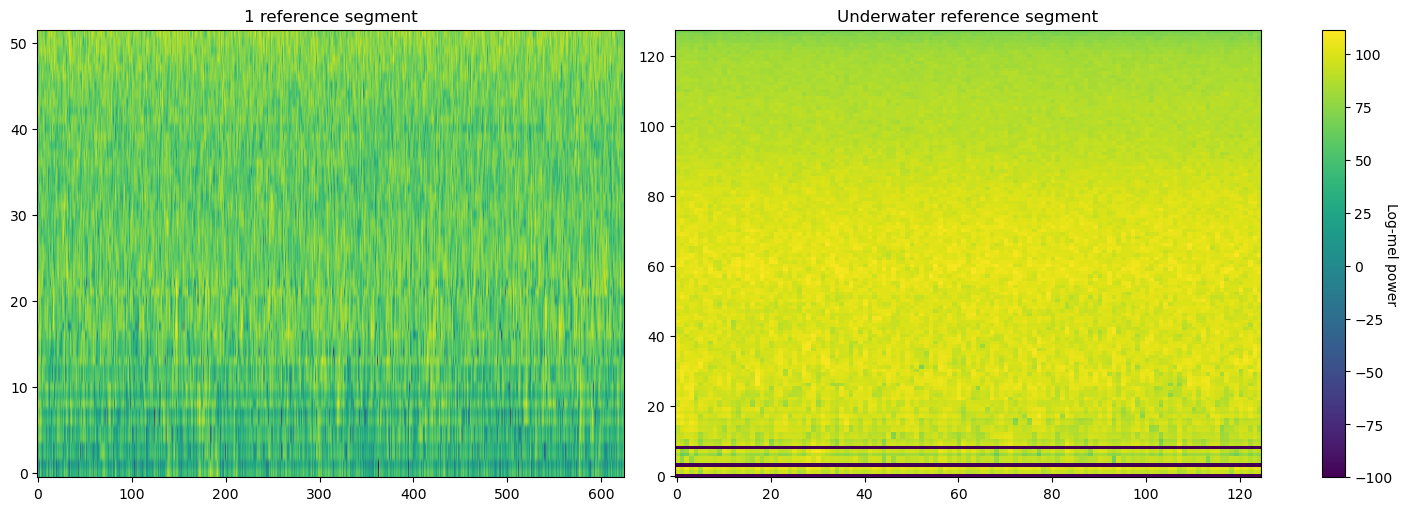

In [9]:
# Segment from current dataset.
spec1 = np.load(val1_path)[key][0]
seg1 = torch.from_numpy(spec1[mels_start:mels_end, i_start:i_end])
# Compare with underwater reference log-mel features.
folder = Path(val1_path).parts[-2]
name = Path(val1_path).name
path = uw_log_mel_path 
spec1_uw = torch.from_numpy(np.load(uw_log_mel_path / name)[key][0])
test_i_start = int((25.0+0) * fps)
test_i_end = int((30.0-4) * fps)
seg1_uw = spec1_uw[0:128, test_i_start:test_i_end]

vmin = torch.min(torch.stack([seg1.min(), seg1_uw.min()])).item()
vmax = torch.max(torch.stack([seg1.max(), seg1_uw.max()])).item()

fig , ax = plt.subplots(1, 2, figsize=(14, 5), constrained_layout=True)
cmap = "viridis"
cbar = fig.colorbar(plt.cm.ScalarMappable(cmap=cmap, norm=plt.Normalize(vmin=vmin, vmax=vmax)), ax=ax.ravel().tolist())
ax[0].imshow(seg1, aspect='auto', origin='lower', cmap=cmap, vmin=torch.min(seg1), vmax=torch.max(seg1))
ax[0].set_title("1 reference segment")  
ax[1].imshow(seg1_uw, aspect='auto', origin='lower', cmap=cmap, vmin=torch.min(seg1_uw), vmax=torch.max(seg1_uw))
ax[1].set_title("Underwater reference segment")
cbar.set_label("Log-mel power", rotation=270)
plt.show()

In [4]:
print("1 reference segment min/max:", seg1.min().item(), "/", seg1.max().item())
print("min/max range =", seg1.max().item() - seg1.min().item())
print("std and mean:", seg1.std().item(), ",", seg1.mean().item())
print("Underwater reference segment min/max:", seg1_uw.min().item(), "/", seg1_uw.max().item())
print("min/max range =", seg1_uw.max().item() - seg1_uw.min().item())
print("std and mean:", seg1_uw.std().item(), ",", seg1_uw.mean().item())

1 reference segment min/max: -73.17660522460938 / -5.960812091827393
min/max range = 67.21579313278198
std and mean: 7.50460958480835 , -34.16572952270508
Underwater reference segment min/max: 46.823394775390625 / 114.03919219970703
min/max range = 67.2157974243164
std and mean: 7.50460958480835 , 85.8342514038086


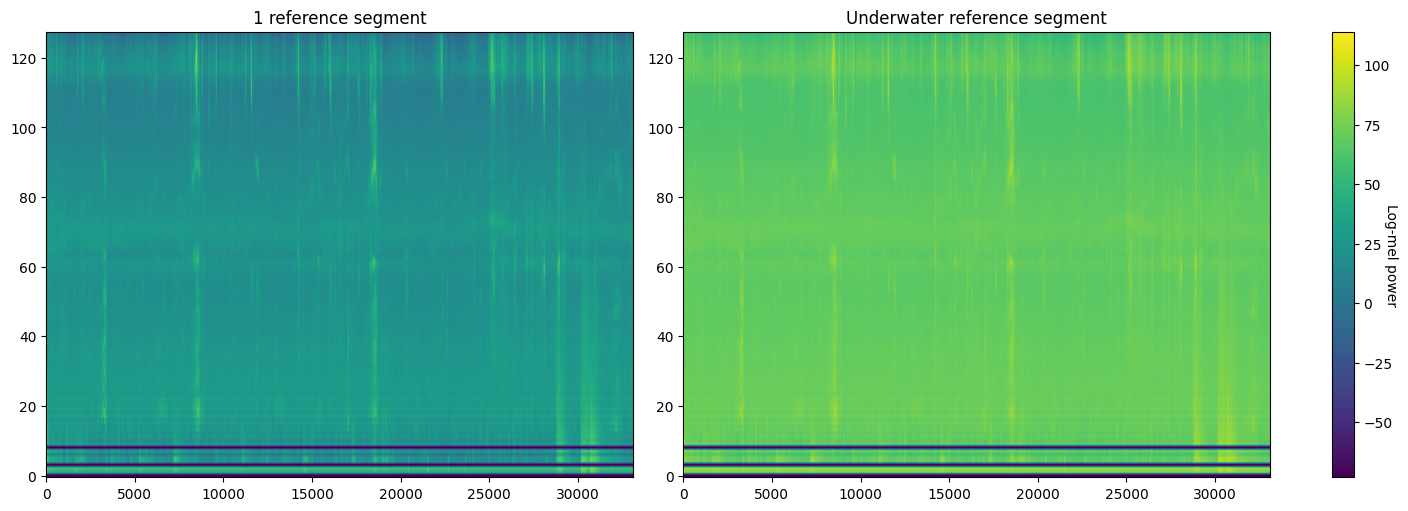

In [5]:
fig, ax = plt.subplots(1, 2, figsize=(14, 5), constrained_layout=True)
cmap = "viridis"
cbar = fig.colorbar(plt.cm.ScalarMappable(cmap=cmap, norm=plt.Normalize(vmin=vmin, vmax=vmax)), ax=ax.ravel().tolist())
spec1 = torch.from_numpy(spec1)
# spec1_uw = torch.from_numpy(spec1_uw)
ax[0].imshow(spec1, aspect='auto', origin='lower', cmap=cmap, vmin=torch.min(spec1), vmax=torch.max(spec1))
ax[0].set_title("1 reference segment")  
ax[1].imshow(spec1_uw, aspect='auto', origin='lower', cmap=cmap, vmin=torch.min(spec1_uw), vmax=torch.max(spec1_uw))
ax[1].set_title("Underwater reference segment")
cbar.set_label("Log-mel power", rotation=270)
plt.show()

In [6]:
print("1 reference min/max:", spec1.min().item(), "/", spec1.max().item())
print("min/max range =", spec1.max().item() - spec1.min().item())
print("std and mean:", spec1.std().item(), ",", spec1.mean().item())
print("Underwater reference min/max:", spec1_uw.min().item(), "/", spec1_uw.max().item())
print("min/max range =", spec1_uw.max().item() - spec1_uw.min().item())
print("std and mean:", spec1_uw.std().item(), ",", spec1_uw.mean().item())

1 reference min/max: -100.0 / 20.569866180419922
min/max range = 120.56986618041992
std and mean: 12.068944931030273 , -40.0388069152832
Underwater reference min/max: -100.0 / 140.56988525390625
min/max range = 240.56988525390625
std and mean: 28.592025756835938 , 77.1274642944336


## Downsampling

torch.Size([52, 300])


Text(0.5, 1.0, 'Downsampled segment')

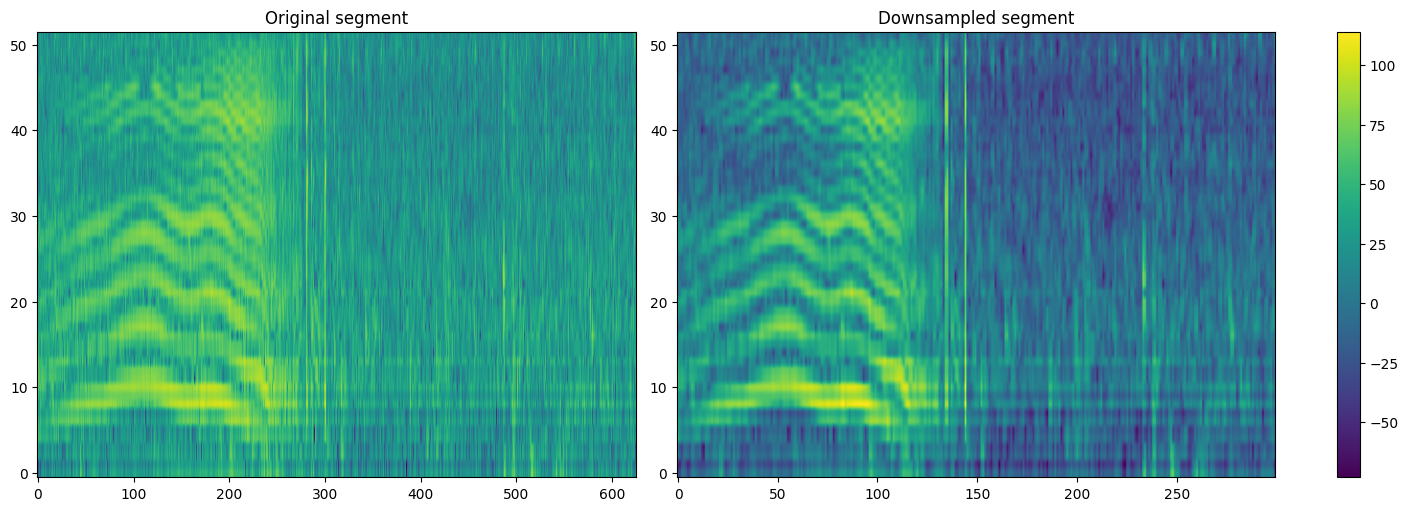

In [7]:
T_target = 300
seg1_ds = futils.downsample_time_avgpool_from_db(seg1_uw, T_target=300)
print(seg1_ds.shape)

fig , ax = plt.subplots(1, 2, figsize=(14, 5), constrained_layout=True)
cmap = "viridis"
cbar = fig.colorbar(plt.cm.ScalarMappable(cmap=cmap, norm=plt.Normalize(vmin=vmin, vmax=vmax)), ax=ax.ravel().tolist())
ax[0].imshow(seg1_uw, aspect='auto', origin='lower', cmap=cmap, vmin=torch.min(seg1_uw), vmax=torch.max(seg1_uw))
ax[0].set_title("Original segment")
ax[1].imshow(seg1_ds, aspect='auto', origin='lower', cmap=cmap, vmin=torch.min(seg1_ds), vmax=torch.max(seg1_ds))
ax[1].set_title("Downsampled segment")

## Downsampling: 3-seconds segments

torch.Size([52, 250])
torch.Size([52, 200])


Text(0.5, 1.0, '3s Downsampled segment')

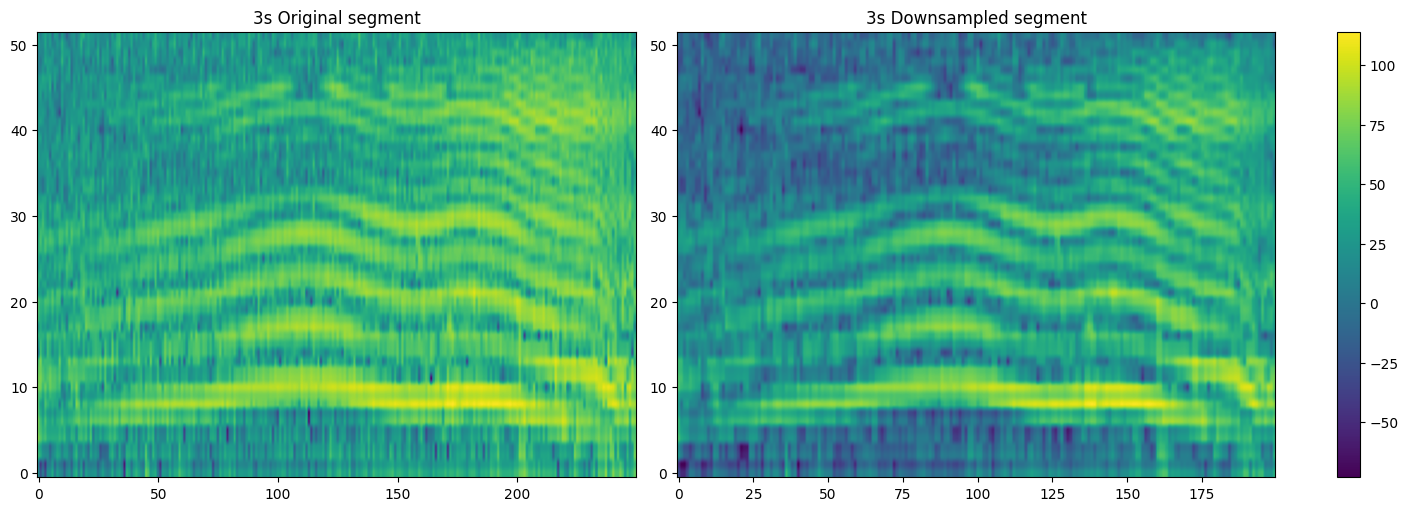

In [8]:
T_target = 200
t1, t2 = 25.0, 27.0
start_3s, end_3s = int(t1 * fps), int(t2 * fps)
seg3 = (spec1_uw[mels_start:mels_end, start_3s:end_3s])
print(seg3.shape)
seg3_ds = futils.downsample_time_avgpool_from_db(seg3, T_target=T_target, ref=1.0, floor_db=None)
print(seg3_ds.shape)

fig , ax = plt.subplots(1, 2, figsize=(14, 5), constrained_layout=True)
cmap = "viridis"
cbar = fig.colorbar(plt.cm.ScalarMappable(cmap=cmap, norm=plt.Normalize(vmin=vmin, vmax=vmax)), ax=ax.ravel().tolist())
ax[0].imshow(seg3, aspect='auto', origin='lower', cmap=cmap, vmin=torch.min(seg3), vmax=torch.max(seg3))
ax[0].set_title("3s Original segment")
ax[1].imshow(seg3_ds, aspect='auto', origin='lower', cmap=cmap, vmin=torch.min(seg3_ds), vmax=torch.max(seg3_ds))
ax[1].set_title("3s Downsampled segment")

## Spectrograms for report section on relevant log-mel bands

In [9]:
report_save_path = Path(r"C:\Users\Lindholm\Dropbox\BSc\report_figures")

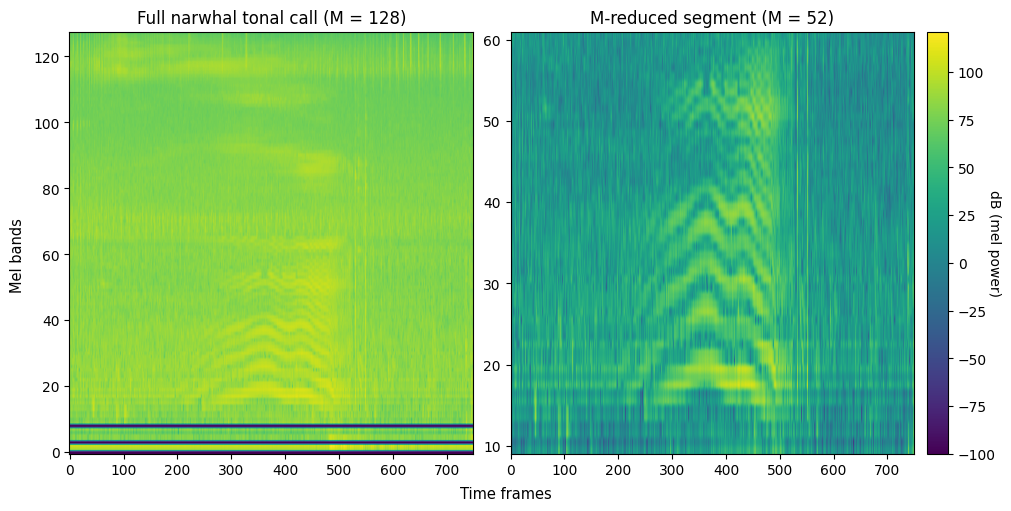

In [10]:
t2_start, t2_end = 23.0, 29.0
i2_start = int(t2_start * fps)
i2_end = int(t2_end * fps)
seg_a = spec1_uw[:, i2_start:i2_end]
seg_b =seg_a[mels_start:mels_end, :]

vmin = torch.min(torch.stack([seg_a.min(), seg_b.min()])).item()
vmax = torch.max(torch.stack([seg_a.max(), seg_b.max()])).item()

fig , ax = plt.subplots(1, 2, figsize=(10, 5), constrained_layout=True)
cmap = "viridis"
cbar = fig.colorbar(plt.cm.ScalarMappable(cmap=cmap, norm=plt.Normalize(vmin=vmin, vmax=vmax)), ax=ax.ravel().tolist(), pad=0.015)
ax[0].imshow(seg_a, aspect='auto', origin='lower', cmap=cmap, vmin=torch.min(seg_a), vmax=torch.max(seg_a))
ax[0].set_title("Full narwhal tonal call (M = 128)")  
ax[1].imshow(seg_b, aspect='auto', origin='lower', cmap=cmap, vmin=torch.min(seg_b), vmax=torch.max(seg_b), extent=[0, seg_b.shape[1], mels_start, mels_end])
ax[1].set_title("M-reduced segment (M = 52)")
fig.supylabel("Mel bands", fontsize=10.5)
fig.supxlabel("Time frames", fontsize=10.5)
cbar.set_label("dB (mel power)", rotation=270, labelpad=4)
fig_name = "m_reduction_comparison.png"
plt.savefig(report_save_path / fig_name, dpi=300)
plt.show()

### Downsampling

torch.Size([52, 625])
torch.Size([52, 300])
torch.Size([52, 100])
torch.Size([52, 25])


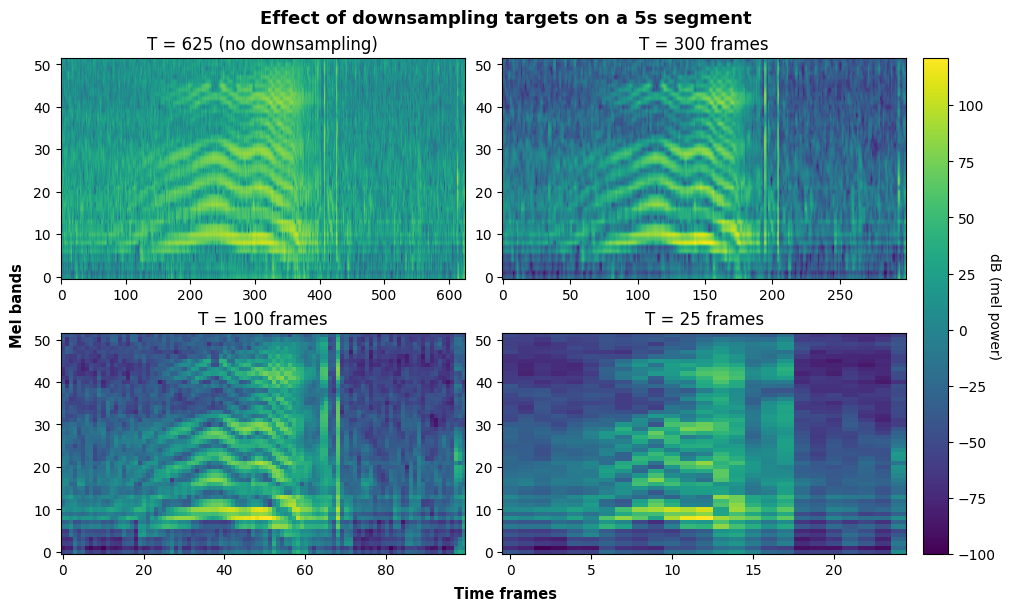

In [11]:
T_target = 200
t1, t2 = 24.0, 29.0
start_3s, end_3s = int(t1 * fps), int(t2 * fps)
seg3 = (spec1_uw[mels_start:mels_end, start_3s:end_3s])
print(seg3.shape)
seg3_ds300 = futils.downsample_time_avgpool_from_db(seg3, T_target=300, ref=1.0, floor_db=None)
print(seg3_ds300.shape)
seg3_ds200 = futils.downsample_time_avgpool_from_db(seg3, T_target=100, ref=1.0, floor_db=None)
print(seg3_ds200.shape)
seg3_ds100 = futils.downsample_time_avgpool_from_db(seg3, T_target=25, ref=1.0, floor_db=None)
print(seg3_ds100.shape)

fig , ax = plt.subplots(2, 2, figsize=(10, 6), constrained_layout=True)
cmap = "viridis"
cbar = fig.colorbar(plt.cm.ScalarMappable(cmap=cmap, norm=plt.Normalize(vmin=vmin, vmax=vmax)), ax=ax.ravel().tolist(), pad=0.02)
ax[0,0].imshow(seg3, aspect='auto', origin='lower', cmap=cmap, vmin=torch.min(seg3), vmax=torch.max(seg3))
ax[0,0].set_title("T = 625 (no downsampling)")
ax[0,1].imshow(seg3_ds300, aspect='auto', origin='lower', cmap=cmap, vmin=torch.min(seg3_ds300), vmax=torch.max(seg3_ds300))
ax[0,1].set_title("T = 300 frames")
ax[1,0].imshow(seg3_ds200, aspect='auto', origin='lower', cmap=cmap, vmin=torch.min(seg3_ds200), vmax=torch.max(seg3_ds200))
ax[1,0].set_title("T = 100 frames")
ax[1,1].imshow(seg3_ds100, aspect='auto', origin='lower', cmap=cmap, vmin=torch.min(seg3_ds100), vmax=torch.max(seg3_ds100))
ax[1,1].set_title("T = 25 frames")
fig.supylabel("Mel bands", fontsize=10.5, fontweight="bold")
fig.supxlabel("Time frames", fontsize=10.5, fontweight="bold")
fig.suptitle("Effect of downsampling targets on a 5s segment", size=13, fontweight="bold")
cbar.set_label("dB (mel power)", rotation=270, labelpad=4)
fig_name = "downsampling_comparison.png"
plt.savefig(report_save_path / fig_name, dpi=300)
plt.show()

### Segment variance

In [12]:
vmin = torch.min(torch.stack([spec1_uw.min(), seg1_uw.min()])).item()
vmax = torch.max(torch.stack([spec1_uw.max(), seg1_uw.max()])).item()
spec1_uw = spec1_uw[mels_start:mels_end, :]

In [13]:
print("Full length feature min/max:", spec1_uw.min().item(), "/", spec1_uw.max().item())
print("min/max range =", spec1_uw.max().item() - spec1_uw.min().item())
print("var and mean:", spec1_uw.var().item(), ",", spec1_uw.mean().item())
print("Feature segment min/max:", seg1_uw.min().item(), "/", seg1_uw.max().item())
print("min/max range =", seg1_uw.max().item() - seg1_uw.min().item())
print("var and mean:", seg1_uw.var().item(), ",", seg1_uw.mean().item())

Full length feature min/max: -100.0 / 123.03575134277344
min/max range = 223.03575134277344
var and mean: 44.531002044677734 , 83.96604919433594
Feature segment min/max: 46.823394775390625 / 114.03919219970703
min/max range = 67.2157974243164
var and mean: 56.31916427612305 , 85.8342514038086


In [14]:
seg1_uw.var().item()

56.31916427612305

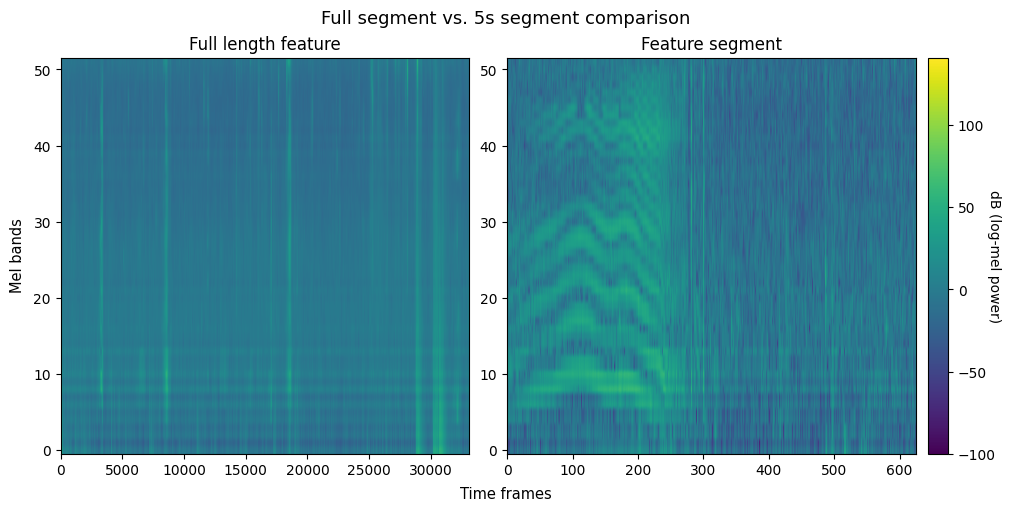

In [15]:
fig , ax = plt.subplots(1, 2, figsize=(10, 5), constrained_layout=True)
cmap = "viridis"
cbar = fig.colorbar(plt.cm.ScalarMappable(cmap=cmap, norm=plt.Normalize(vmin=vmin, vmax=vmax)), ax=ax.ravel().tolist(), pad=0.015)
ax[0].imshow(spec1_uw, aspect='auto', origin='lower', cmap=cmap, vmin=seg1_uw.min(), vmax=vmax)
ax[0].set_title("Full length feature")  
ax[1].imshow(seg1_uw, aspect='auto', origin='lower', cmap=cmap, vmin=seg1_uw.min(), vmax=vmax)
ax[1].set_title("Feature segment")
fig.suptitle("Full segment vs. 5s segment comparison", size=13)
fig.supylabel("Mel bands", fontsize=10.5)
fig.supxlabel("Time frames", fontsize=10.5)
cbar.set_label("dB (log-mel power)", rotation=270, labelpad=4)
fig_name = "full_segment_comparison.png"
plt.savefig(report_save_path / fig_name, dpi=300)
plt.show()

## Spectrogram inspection

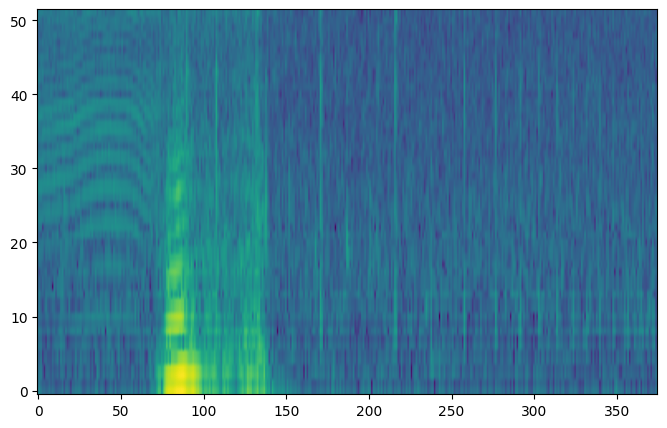

In [46]:
file_path = r"D:\logmel_outputs_9979\Tracy_6230\6230.220915010000.npz" 
# 100, 125, 180, 220, 
spec = np.load(file_path)[key][0]
i_start = 222
i_end = i_start + 3
seg = spec[mels_start:mels_end, int(i_start*fps):int(i_end*fps)]
seg_ds = futils.downsample_time_avgpool_from_db(torch.from_numpy(seg), T_target=300)
plt.figure(figsize=(8, 5))
plt.imshow(seg, aspect='auto', origin='lower', cmap='viridis')
plt.show()